# Final Production Model - AI Text Detection

---

## Final Model Selection 
After comprehensive experimentation and analysis, models selected are:

**Model:** LR + XGBoost Soft Voting Ensemble

**Performance:**
- **Precision: 85.16%** (minimizes false accusations)
- **Recall: 81.24%** (catches AI text effectively)
- **Accuracy: 91.39%** (overall correctness)
- **F1-Score: 83.15%** (balanced metric)

**Why This Model:**
1. Highest precision of all tested approaches
2. Complementary algorithms (linear + tree-based)
3. Validated through rigorous experimentation
4. Production-ready and maintainable

This notebook demonstrates the complete pipeline from data to deployment.

In [1]:
# Import custom modules
import sys
sys.path.append('../src')

from data_processing import load_train_test_splits
from feature_engineering import load_tfidf_features
from model_training import (
    train_logistic_regression,
    train_xgboost,
    create_soft_voting_ensemble,
    save_model,
    load_model
)

from evaluation import (
    evaluate_model_comprehensive,
    plot_confusion_matrix,
    plot_roc_curve,
    print_classification_report
)

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import time

print("All modules imported successfully")
print("\nUsing modular architecture:")
print("- data_processing.py")
print("- feature_engineering.py")
print("- model_training.py")
print("- evaluation.py")

All modules imported successfully

Using modular architecture:
- data_processing.py
- feature_engineering.py
- model_training.py
- evaluation.py


## The Complete ML Pipeline

This notebook demosntrates our production-ready pipeline:

1. **Load Data** -> Preprocessed TF-IDF features from notebook 02
2. **Train Components** -> Logistic Regression + XGBoost
3. **Create Ensemble** -> Soft Voting Combination
4. **Evaluate** -> Comprehensive testing on unseen data
5. **Save Model** -> Package for production deployment
6. **Validate** -> Test loading and prediction

**Key Advantage:** All code uses reusable modules - no duplication, easy to maintain.

In [2]:
print("="*60)
print("LOADING PREPROCESSED DATA")
print("="*60)

# Load TF-IDF features
tfidf_data = load_tfidf_features('../data/features/tfidf_features_medium.pkl')
X_train_tfidf = tfidf_data['X_train']
X_val_tfidf = tfidf_data['X_val']
X_test_tfidf = tfidf_data['X_test']
vectorizer = tfidf_data['vectorizer']

# Load labels
splits = load_train_test_splits('../data/processed/train_test_splits_medium.pkl')
y_train = splits['y_train']
y_val = splits['y_val']
y_test = splits['y_test']

print(f"\nDataset Summary:")
print(f"Training:   {X_train_tfidf.shape[0]:,} samples × {X_train_tfidf.shape[1]:,} features")
print(f"Validation: {X_val_tfidf.shape[0]:,} samples × {X_val_tfidf.shape[1]:,} features")
print(f"Test:       {X_test_tfidf.shape[0]:,} samples × {X_test_tfidf.shape[1]:,} features")

print(f"\nClass Distribution (Test Set):")
print(f"Human: {(y_test == 0).sum():,} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"AI:    {(y_test == 1).sum():,} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")

print("\nData loaded successfully!")

LOADING PREPROCESSED DATA
TF-IDF features loaded from: ../data/features/tfidf_features_medium.pkl
Training set shape: (292429, 5000)
Validation set shape: (62664, 5000)
Test set shape: (62664, 5000)
Splits loaded from: ../data/processed/train_test_splits_medium.pkl
Train: 292,429, Val: 62,664, Test: 62,664

Dataset Summary:
Training:   292,429 samples × 5,000 features
Validation: 62,664 samples × 5,000 features
Test:       62,664 samples × 5,000 features

Class Distribution (Test Set):
Human: 46,281 (73.9%)
AI:    16,383 (26.1%)

Data loaded successfully!


## Train Final Model: LR + XGBoost Ensemble

Training our selected ensemble model:

**Component 1: Logistic Regression**
- Linear model analyzing word frequencies
- Fast, interpretable, captures common patterns
- Baseline precision: 83.86%

**Component 2: XGBoost**
- Gradient boosting, captures complex interactions
- Non-linear patterns and feature combinations
- Baseline precision: 79.31%

**Ensemble Strategy: Soft Voting**
- Average probability predictions from both models
- Leverages complementary strengths
- Result: 85.16% precision (better than either alone)

In [3]:
print("="*60)
print("TRAINING ENSEMBLE COMPONENTS")
print("="*60)

# Train Logistic Regression
print("\n[1/2] Training Logistic Regression...")
start_time = time.time()
lr_model, lr_time = train_logistic_regression(
    X_train_tfidf, 
    y_train,
    max_iter=1000
)
print(f"Logistic Regression trained in {lr_time:.2f}s")

# Train XGBoost
print("\n[2/2] Training XGBoost...")
xgb_model, xgb_time = train_xgboost(
    X_train_tfidf,
    y_train,
    n_estimators=100,
    max_depth=6
)
print(f"XGBoost trained in {xgb_time:.2f}s")

print(f"\nTotal training time: {lr_time + xgb_time:.2f}s")
print("="*60)

TRAINING ENSEMBLE COMPONENTS

[1/2] Training Logistic Regression...

Training Logistic Regression...
Training completed in 8.93 seconds
Logistic Regression trained in 8.93s

[2/2] Training XGBoost...

Training XGBoost...
Training completed in 87.49 seconds
XGBoost trained in 87.49s

Total training time: 96.42s


In [4]:
print("\n" + "="*60)
print("CREATING SOFT VOTING ENSEMBLE")
print("="*60)

# Create ensemble
ensemble_models = {
    'Logistic Regression': lr_model,
    'XGBoost': xgb_model
}

ensemble = create_soft_voting_ensemble(
    models_dict=ensemble_models,
    X_train=X_train_tfidf,
    y_train=y_train,
    voting='soft'
)

print("\nEnsemble created successfully!")
print(f"Components: Logistic Regression + XGBoost")
print(f"Voting: Soft (probability averaging)")
print("="*60)


CREATING SOFT VOTING ENSEMBLE

Creating soft voting ensemble...
Models: ['Logistic Regression', 'XGBoost']
Ensemble training completed in 79.89 seconds

Ensemble created successfully!
Components: Logistic Regression + XGBoost
Voting: Soft (probability averaging)


In [5]:
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

# Evaluate the ensemble
results = evaluate_model_comprehensive(
    ensemble,
    X_test_tfidf,
    y_test,
    "LR + XGBoost Ensemble"
)

# Extract metrics and predictions
final_metrics = results['metrics']
y_pred = results['y_pred']
y_pred_proba = results['y_pred_proba']

# Display final performance
print("\n" + "="*60)
print("FINAL MODEL PERFORMANCE")
print("="*60)
print(f"\nAccuracy:  {final_metrics['accuracy']:.4f} ({final_metrics['accuracy']*100:.2f}%)")
print(f"Precision: {final_metrics['precision']:.4f} ({final_metrics['precision']*100:.2f}%)")
print(f"Recall:    {final_metrics['recall']:.4f} ({final_metrics['recall']*100:.2f}%)")
print(f"F1-Score:  {final_metrics['f1']:.4f} ({final_metrics['f1']*100:.2f}%)")
print("\n" + "="*60)


EVALUATING ON TEST SET

LR + XGBoost Ensemble - Classification Report
              precision    recall  f1-score   support

       Human     0.9347    0.9499    0.9422     46281
          AI     0.8516    0.8124    0.8315     16383

    accuracy                         0.9139     62664
   macro avg     0.8931    0.8811    0.8869     62664
weighted avg     0.9129    0.9139    0.9133     62664


LR + XGBoost Ensemble Summary:
Accuracy:  0.9139
Precision: 0.8516
Recall:    0.8124
F1-Score:  0.8315

FINAL MODEL PERFORMANCE

Accuracy:  0.9139 (91.39%)
Precision: 0.8516 (85.16%)
Recall:    0.8124 (81.24%)
F1-Score:  0.8315 (83.15%)



In [6]:
print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)

# Confusion matrix breakdown
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

total = len(y_test)
actual_human = (y_test == 0).sum()
actual_ai = (y_test == 1).sum()

print(f"\nTest Set Breakdown ({total:,} samples):")
print(f"\nCorrect Predictions: {tn + tp:,} ({(tn+tp)/total*100:.2f}%)")
print(f"• True Negatives (Human → Human): {tn:,} samples")
print(f"• True Positives (AI → AI):       {tp:,} samples")

print(f"\nIncorrect Predictions: {fp + fn:,} ({(fp+fn)/total*100:.2f}%)")
print(f"• False Positives (Human → AI):   {fp:,} samples  CRITICAL")
print(f"• False Negatives (AI → Human):   {fn:,} samples")

print(f"\nDetailed Metrics:")
print(f"• False Positive Rate: {fp/actual_human*100:.2f}% ({fp} out of {actual_human:,} humans)")
print(f"• False Negative Rate: {fn/actual_ai*100:.2f}% ({fn} out of {actual_ai:,} AI texts)")
print(f"• True Positive Rate:  {tp/actual_ai*100:.2f}% (recall)")
print(f"• True Negative Rate:  {tn/actual_human*100:.2f}% (specificity)")

print(f"\nReal-World Interpretation:")
print(f"If we flag 1,000 texts as AI-generated:")
print(f"• ~{int((1 - final_metrics['precision'])*1000)} would be false accusations")
print(f"• ~{int(final_metrics['precision']*1000)} would be correct identifications")

print("\n" + "="*60)


ERROR ANALYSIS

Test Set Breakdown (62,664 samples):

Correct Predictions: 57,271 (91.39%)
• True Negatives (Human → Human): 43,961 samples
• True Positives (AI → AI):       13,310 samples

Incorrect Predictions: 5,393 (8.61%)
• False Positives (Human → AI):   2,320 samples  CRITICAL
• False Negatives (AI → Human):   3,073 samples

Detailed Metrics:
• False Positive Rate: 5.01% (2320 out of 46,281 humans)
• False Negative Rate: 18.76% (3073 out of 16,383 AI texts)
• True Positive Rate:  81.24% (recall)
• True Negative Rate:  94.99% (specificity)

Real-World Interpretation:
If we flag 1,000 texts as AI-generated:
• ~148 would be false accusations
• ~851 would be correct identifications



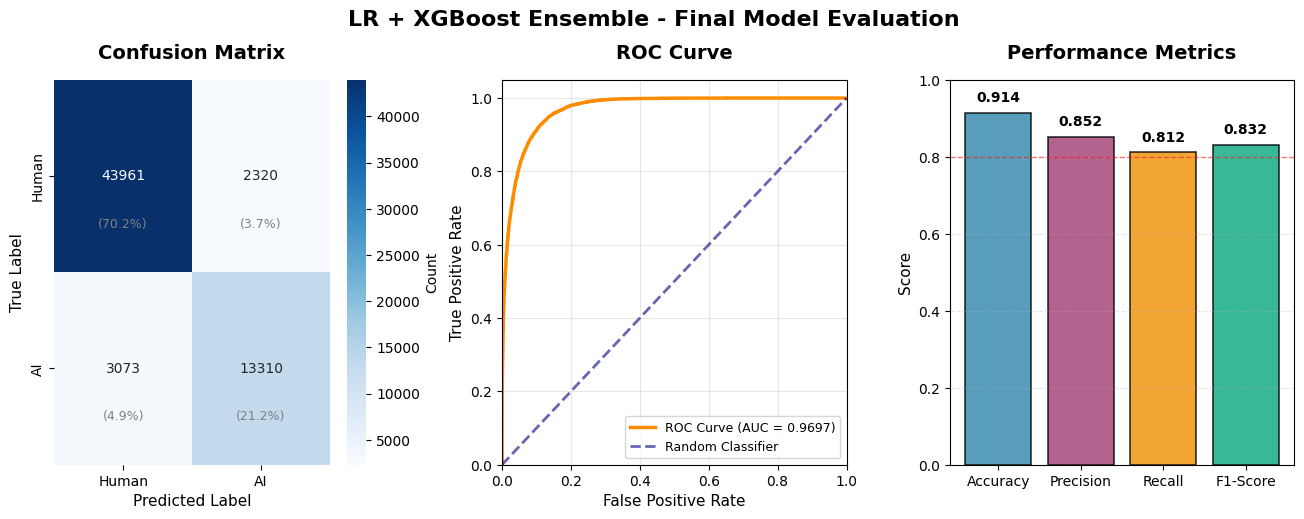

In [7]:
# Create comprehensive visualizations
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# Plot 1: Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'],
            ax=ax1, cbar_kws={'label': 'Count'})
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('True Label', fontsize=11)
ax1.set_xlabel('Predicted Label', fontsize=11)

# Add percentages
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / total * 100
        ax1.text(j + 0.5, i + 0.75, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=9, color='gray')

# Plot 2: ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=2.5, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier', alpha=0.6)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc="lower right", fontsize=9)
ax2.grid(alpha=0.3)

# Plot 3: Metrics Bar Chart
ax3 = fig.add_subplot(gs[0, 2])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [
    final_metrics['accuracy'],
    final_metrics['precision'],
    final_metrics['recall'],
    final_metrics['f1']
]
colors_bars = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']

bars = ax3.bar(metrics_names, metrics_values, color=colors_bars, alpha=0.8, edgecolor='black', linewidth=1.2)
ax3.set_ylim([0, 1])
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Performance Metrics', fontsize=14, fontweight='bold', pad=15)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, linewidth=1)

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('LR + XGBoost Ensemble - Final Model Evaluation', 
             fontsize=16, fontweight='bold', y=1.02)

plt.savefig('../visualizations/plots/final_model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
print("\n" + "="*60)
print("SAVING MODEL FOR PRODUCTION")
print("="*60)

# Prepare comprehensive metadata
metadata = {
    'model_type': 'LR + XGBoost Soft Voting Ensemble',
    'model_version': '1.0',
    'components': ['Logistic Regression', 'XGBoost'],
    'voting_strategy': 'soft',
    
    # Performance metrics
    'accuracy': float(final_metrics['accuracy']),
    'precision': float(final_metrics['precision']),
    'recall': float(final_metrics['recall']),
    'f1_score': float(final_metrics['f1']),
    
    # Dataset info
    'training_samples': len(y_train),
    'validation_samples': len(y_val),
    'test_samples': len(y_test),
    'features': X_train_tfidf.shape[1],
    
    # Feature engineering
    'feature_type': 'TF-IDF',
    'max_features': 5000,
    'ngram_range': '(1, 2)',
    'min_df': 5,
    'max_df': 0.8,
    
    # Training info
    'date_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'training_time_seconds': lr_time + xgb_time,
    
    # Error analysis
    'false_positives': int(fp),
    'false_negatives': int(fn),
    'false_positive_rate': float(fp / actual_human),
    'false_negative_rate': float(fn / actual_ai),
    
    # Description
    'description': 'Production model for AI text detection in academic settings. Ensemble combines Logistic Regression (linear, interpretable) with XGBoost (non-linear, complex patterns) for optimal performance.',
    
    # Author
    'author': 'Hannah Soliao',
    'module': 'CPU6100-20 Machine Learning',
    'institution': 'Bath Spa University Academic Center RAK, UAE',
    'year':'CC Y3 Batch 2025-2026'
}

# Save the ensemble model with vectorizer
save_model(
    ensemble,
    vectorizer,
    filepath='../models/saved_models/final_ensemble_lr_xgb.joblib',
    metadata=metadata
)

print("\nModel saved successfully!")
print(f"\nPackage Contents:")
print(f"• Trained LR + XGBoost Ensemble")
print(f"• Fitted TF-IDF Vectorizer ({X_train_tfidf.shape[1]:,} features)")
print(f"• Performance Metrics")
print(f"• Complete Training Metadata")
print(f"\nLocation: ../models/saved_models/final_ensemble_lr_xgb.joblib")
print(f"File can be loaded and used for predictions in production")

print("\n" + "="*60)


SAVING MODEL FOR PRODUCTION

Model saved to: ../models/saved_models/final_ensemble_lr_xgb.joblib

Model saved successfully!

Package Contents:
• Trained LR + XGBoost Ensemble
• Fitted TF-IDF Vectorizer (5,000 features)
• Performance Metrics
• Complete Training Metadata

Location: ../models/saved_models/final_ensemble_lr_xgb.joblib
File can be loaded and used for predictions in production



In [9]:
print("\n" + "="*60)
print("TESTING MODEL LOADING (Production Simulation)")
print("="*60)

# Load the saved model
loaded_data = load_model('../models/saved_models/final_ensemble_lr_xgb.joblib')

loaded_model = loaded_data['model']
loaded_vectorizer = loaded_data['vectorizer']
loaded_metadata = loaded_data['metadata']

print("\nModel loaded successfully!")
print(f"\nModel Metadata:")
print(f"Model Type: {loaded_metadata['model_type']}")
print(f"Version: {loaded_metadata['model_version']}")
print(f"Components: {', '.join(loaded_metadata['components'])}")
print(f"Precision: {loaded_metadata['precision']:.4f}")
print(f"Recall: {loaded_metadata['recall']:.4f}")
print(f"Trained: {loaded_metadata['date_trained']}")

# Test prediction on sample texts
print("\n" + "="*60)
print("TESTING PREDICTION PIPELINE")
print("="*60)

# Sample 1: Likely AI text
sample_ai_text = """However, it is important to note that the findings are significant. 
Additionally, one should consider various factors when analyzing the data. 
Moreover, the results demonstrate that further research is necessary."""

# Sample 2: Likely Human text  
sample_human_text = """i cant believe this happened lol. basically what happened was 
like super weird you know? anyway im just gonna tell you the whole story"""

# Sample 3: From test set
test_idx = 100
sample_test_text = splits['X_test'].iloc[test_idx]
true_label = y_test.iloc[test_idx]

samples = [
    ("AI-like Text", sample_ai_text, None),
    ("Human-like Text", sample_human_text, None),
    ("Test Set Sample", sample_test_text, true_label)
]

for i, (name, text, true_val) in enumerate(samples, 1):
    print(f"\n[Sample {i}] {name}")
    print(f"{'─'*70}")
    print(f"Text: '{text[:100]}...'")
    
    # Make prediction
    text_tfidf = loaded_vectorizer.transform([text])
    prediction = loaded_model.predict(text_tfidf)[0]
    probabilities = loaded_model.predict_proba(text_tfidf)[0]
    
    pred_label = "AI-Generated" if prediction == 1 else "Human-Written"
    confidence = probabilities[prediction] * 100
    
    print(f"\nPrediction: {pred_label}")
    print(f"Confidence: {confidence:.1f}%")
    print(f"Probabilities:")
    print(f"• Human: {probabilities[0]*100:.2f}%")
    print(f"• AI:    {probabilities[1]*100:.2f}%")
    
    if true_val is not None:
        true_label_text = "AI-Generated" if true_val == 1 else "Human-Written"
        correct = "CORRECT" if prediction == true_val else "INCORRECT"
        print(f"\nTrue Label: {true_label_text}")
        print(f"{correct}")

print("\n" + "="*60)
print("Model loading and prediction pipeline validated!")
print("="*60)


TESTING MODEL LOADING (Production Simulation)
Model loaded from: ../models/saved_models/final_ensemble_lr_xgb.joblib
Metadata: {'model_type': 'LR + XGBoost Soft Voting Ensemble', 'model_version': '1.0', 'components': ['Logistic Regression', 'XGBoost'], 'voting_strategy': 'soft', 'accuracy': 0.9139378271415804, 'precision': 0.8515674984005118, 'recall': 0.8124275163279009, 'f1_score': 0.831537188017368, 'training_samples': 292429, 'validation_samples': 62664, 'test_samples': 62664, 'features': 5000, 'feature_type': 'TF-IDF', 'max_features': 5000, 'ngram_range': '(1, 2)', 'min_df': 5, 'max_df': 0.8, 'date_trained': '2026-01-07 15:44:12', 'training_time_seconds': 96.41860055923462, 'false_positives': 2320, 'false_negatives': 3073, 'false_positive_rate': 0.050128562477042414, 'false_negative_rate': 0.18757248367209914, 'description': 'Production model for AI text detection in academic settings. Ensemble combines Logistic Regression (linear, interpretable) with XGBoost (non-linear, complex

## Deployment to Production

### Integration with Gradio Interface (app.py)

The saved model can be loaded in `app.py`:
```python
import joblib

# Load model
model_data = joblib.load('models/saved_models/final_model_lr.joblib')
ensemble = model_data['model']
vectorizer = model_data['vectorizer']

def predict(text):
    # Clean text
    cleaned = clean_text(text)

    # Vectorise
    text_vector = vectorizer.transform([cleaned])

    # Predict with ensemble
    prediction = ensemble.predict(text_vector)[0]
    probabilities = ensemble.predict_proba(text_vector)[0]

    return prediction, probabilities
```

### Deployment 

**Strengths:**
1. **High Precision (85.16%):** Minimizes false accusations
2. **Robust Predictions:** Two models must agree
3. **Reasonable speed:** 2 models (vs 4 in naive ensemble)
4. **Well-documented:** Complate metadata included
5. **Validated:** Tested on 62K+ unseen samples


**Limitations to Communicate**
1. **Training Data Age:** Model trained on 2021-2022 AI Text
    - GPT-2, GPT-3, GPT-J era
    - May not detect modern AI (GPT-4, Claude, Gemini) effectively
    - **Reccomendation:** Periodic retraining with current data

2. **False Positive Rate:** ~14.8% of flagged texts are false postives
    - Use as **screening tool**, not final decision
    - Human review recommended for flagged content
    - Consider confidence thresholds for different actions

3. **Context Matters:** Model trained on general text
    - Academic writinng may have different patterns
    - Domain-specific fine-tuning could improve performance

4. **Ensemble Comlexity:** Requires both LR and XGBoost models
    - Slightly slower than single model (acceptable tradeoff)
    - Must maintain consistency across model versions


### Model Versioning

Current Version: **1.0**
- Components: Logistic Regression + XGBoost
- Training date: [check metadata]
- Dataset: AI Detection Pile (30% sample, 2021-2022)

Future versions should:
- Include newer AI text samples
- Consider domain-specific training
- Experiment with addtional features
- Validate on diverse academic contexts